In [1]:
# Medicare Provider Analytics Using Apache Spark

## Notebook 4 – Analytics and Business Insights

# Course:CS-675 Big Data Management & Analytics  
#Author:Judi-Ann Beckford  

### Objective

# Analyze the integrated Medicare provider-service dataset to identify patterns in service utilization, estimated Medicare payments, provider specialties, procedures, and geographic distribution.

### Important Measurement Note

# The source dataset reports average Medicare payment per service rather than a claim-level total payment field. Therefore, estimated total Medicare payment is calculated as:

# Total Services × Average Medicare Payment

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

import matplotlib.pyplot as plt
import os

In [3]:
spark = (
    SparkSession.builder
    .appName("Medicare Analytics and Business Insights")
    .config("spark.sql.shuffle.partitions", "24")
    .config("spark.default.parallelism", "24")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.parquet.compression.codec", "snappy")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print("Spark version:", spark.version)
print("Spark master:", spark.sparkContext.master)
print(
    "Driver memory:",
    spark.sparkContext.getConf().get("spark.driver.memory")
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/29 19:56:49 WARN Utils: Your hostname, Judi-Anns-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.187 instead (on interface en0)
26/07/29 19:56:49 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
26/07/29 19:56:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/29 19:56:50 WARN Utils: Service 'SparkUI' could no

Spark version: 4.1.2
Spark master: local[6]
Driver memory: 6g


In [4]:
master_path = "../data/processed/master_provider_services"

print("Master dataset exists:", os.path.exists(master_path))

master_df = spark.read.parquet(master_path)

print("Master dataset loaded.")

Master dataset exists: True


Master dataset loaded.


In [5]:
master_rows = master_df.count()
master_columns = len(master_df.columns)
master_partitions = master_df.rdd.getNumPartitions()

print(f"Rows: {master_rows:,}")
print(f"Columns: {master_columns}")
print(f"Spark partitions: {master_partitions}")

[Stage 2:=====================================================>   (45 + 3) / 48]

Rows: 9,781,673
Columns: 25
Spark partitions: 48


In [6]:
master_df.select(
    "NPI",
    "PROVIDER_SPECIALTY",
    "PROVIDER_STATE",
    "ENROLLMENT_PROVIDER_TYPE",
    "HCPCS_CODE",
    "HCPCS_DESCRIPTION",
    "TOTAL_SERVICES",
    "AVG_MEDICARE_PAYMENT",
    "ESTIMATED_TOTAL_MEDICARE_PAYMENT"
).show(10, truncate=False)

+----------+--------------------------+--------------+--------------------------------------------+----------+------------------------------------------------------------------------------------------------------------------------------+--------------+--------------------+--------------------------------+
|NPI       |PROVIDER_SPECIALTY        |PROVIDER_STATE|ENROLLMENT_PROVIDER_TYPE                    |HCPCS_CODE|HCPCS_DESCRIPTION                                                                                                             |TOTAL_SERVICES|AVG_MEDICARE_PAYMENT|ESTIMATED_TOTAL_MEDICARE_PAYMENT|
+----------+--------------------------+--------------+--------------------------------------------+----------+------------------------------------------------------------------------------------------------------------------------------+--------------+--------------------+--------------------------------+
|1003017351|Ambulatory Surgical Center|CA            |PART B SUPPLIER - AMBULAT

In [7]:
# Research Question 1: Which provider specialties generate the highest estimated Medicare payments?
specialty_payment_summary = (
    master_df
    .filter(F.col("PROVIDER_SPECIALTY").isNotNull())
    .groupBy("PROVIDER_SPECIALTY")
    .agg(
        F.sum("ESTIMATED_TOTAL_MEDICARE_PAYMENT")
            .alias("ESTIMATED_MEDICARE_PAYMENT"),
        F.sum("TOTAL_SERVICES").alias("TOTAL_SERVICES"),
        F.countDistinct("NPI").alias("UNIQUE_PROVIDERS"),
        F.avg("AVG_MEDICARE_PAYMENT")
            .alias("AVERAGE_PAYMENT_PER_SERVICE")
    )
    .orderBy(F.desc("ESTIMATED_MEDICARE_PAYMENT"))
)

specialty_payment_summary.show(20, truncate=False)

[Stage 8:============================>                            (12 + 6) / 24]

+--------------------------------------+--------------------------+--------------------+----------------+---------------------------+
|PROVIDER_SPECIALTY                    |ESTIMATED_MEDICARE_PAYMENT|TOTAL_SERVICES      |UNIQUE_PROVIDERS|AVERAGE_PAYMENT_PER_SERVICE|
+--------------------------------------+--------------------------+--------------------+----------------+---------------------------+
|Ophthalmology                         |7.776129741899211E9       |1.493745847E8       |17025           |127.49632039218594         |
|Internal Medicine                     |7.006090022178669E9       |1.402584165E8       |90053           |68.04318636497769          |
|Clinical Laboratory                   |6.914956096288783E9       |3.043538328E8       |2690            |39.35594942314917          |
|Nurse Practitioner                    |6.746217831217227E9       |1.6348771770000002E8|187676          |53.59986394791505          |
|Ambulatory Surgical Center            |4.866509296249826E9   

In [8]:
specialty_payment_display = (
    specialty_payment_summary
    .select(
        "PROVIDER_SPECIALTY",
        F.round("ESTIMATED_MEDICARE_PAYMENT", 2)
            .alias("ESTIMATED_MEDICARE_PAYMENT"),
        F.round("TOTAL_SERVICES", 0).alias("TOTAL_SERVICES"),
        "UNIQUE_PROVIDERS",
        F.round("AVERAGE_PAYMENT_PER_SERVICE", 2)
            .alias("AVERAGE_PAYMENT_PER_SERVICE")
    )
)

specialty_payment_display.show(15, truncate=False)

[Stage 12:==========================================>             (36 + 6) / 48]

+--------------------------------------+--------------------------+--------------+----------------+---------------------------+
|PROVIDER_SPECIALTY                    |ESTIMATED_MEDICARE_PAYMENT|TOTAL_SERVICES|UNIQUE_PROVIDERS|AVERAGE_PAYMENT_PER_SERVICE|
+--------------------------------------+--------------------------+--------------+----------------+---------------------------+
|Ophthalmology                         |7.7761297419E9            |1.49374585E8  |17025           |127.5                      |
|Internal Medicine                     |7.00609002218E9           |1.40258417E8  |90053           |68.04                      |
|Clinical Laboratory                   |6.91495609629E9           |3.04353833E8  |2690            |39.36                      |
|Nurse Practitioner                    |6.74621783122E9           |1.63487718E8  |187676          |53.6                       |
|Ambulatory Surgical Center            |4.86650929625E9           |4.8421423E7   |5411            |1301.

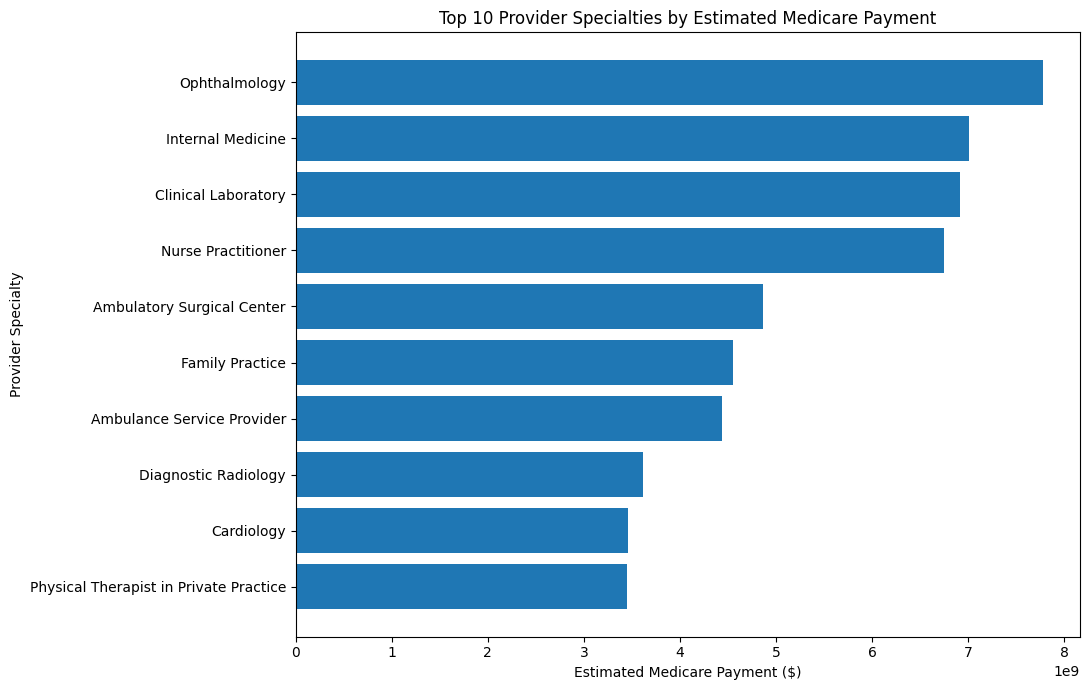

In [9]:
top_specialties_pd = (
    specialty_payment_display
    .limit(10)
    .toPandas()
    .sort_values("ESTIMATED_MEDICARE_PAYMENT")
)

plt.figure(figsize=(11, 7))
plt.barh(
    top_specialties_pd["PROVIDER_SPECIALTY"],
    top_specialties_pd["ESTIMATED_MEDICARE_PAYMENT"]
)
plt.title("Top 10 Provider Specialties by Estimated Medicare Payment")
plt.xlabel("Estimated Medicare Payment ($)")
plt.ylabel("Provider Specialty")
plt.tight_layout()
plt.show()

In [10]:
#Research Question 2: Which HCPCS procedures account for the greatest estimated Medicare spending?
hcpcs_payment_summary = (
    master_df
    .filter(F.col("HCPCS_CODE").isNotNull())
    .groupBy("HCPCS_CODE", "HCPCS_DESCRIPTION")
    .agg(
        F.sum("ESTIMATED_TOTAL_MEDICARE_PAYMENT")
            .alias("ESTIMATED_MEDICARE_PAYMENT"),
        F.sum("TOTAL_SERVICES").alias("TOTAL_SERVICES"),
        F.countDistinct("NPI").alias("UNIQUE_PROVIDERS"),
        F.avg("AVG_MEDICARE_PAYMENT")
            .alias("AVERAGE_PAYMENT_PER_SERVICE")
    )
    .orderBy(F.desc("ESTIMATED_MEDICARE_PAYMENT"))
)

hcpcs_payment_summary.select(
    "HCPCS_CODE",
    "HCPCS_DESCRIPTION",
    F.round("ESTIMATED_MEDICARE_PAYMENT", 2)
        .alias("ESTIMATED_MEDICARE_PAYMENT"),
    F.round("TOTAL_SERVICES", 0).alias("TOTAL_SERVICES"),
    "UNIQUE_PROVIDERS",
    F.round("AVERAGE_PAYMENT_PER_SERVICE", 2)
        .alias("AVERAGE_PAYMENT_PER_SERVICE")
).show(20, truncate=False)

[Stage 26:==========================================>             (18 + 6) / 24]

+----------+----------------------------------------------------------------------------------------------------------------------------------+--------------------------+--------------+----------------+---------------------------+
|HCPCS_CODE|HCPCS_DESCRIPTION                                                                                                                 |ESTIMATED_MEDICARE_PAYMENT|TOTAL_SERVICES|UNIQUE_PROVIDERS|AVERAGE_PAYMENT_PER_SERVICE|
+----------+----------------------------------------------------------------------------------------------------------------------------------+--------------------------+--------------+----------------+---------------------------+
|99214     |Established patient office or other outpatient visit with moderate level of decision making, if using time, 30 minutes or more    |8.42941725998E9           |1.02377857E8  |498045          |79.29                      |
|99213     |Established patient office or other outpatient visit with low le

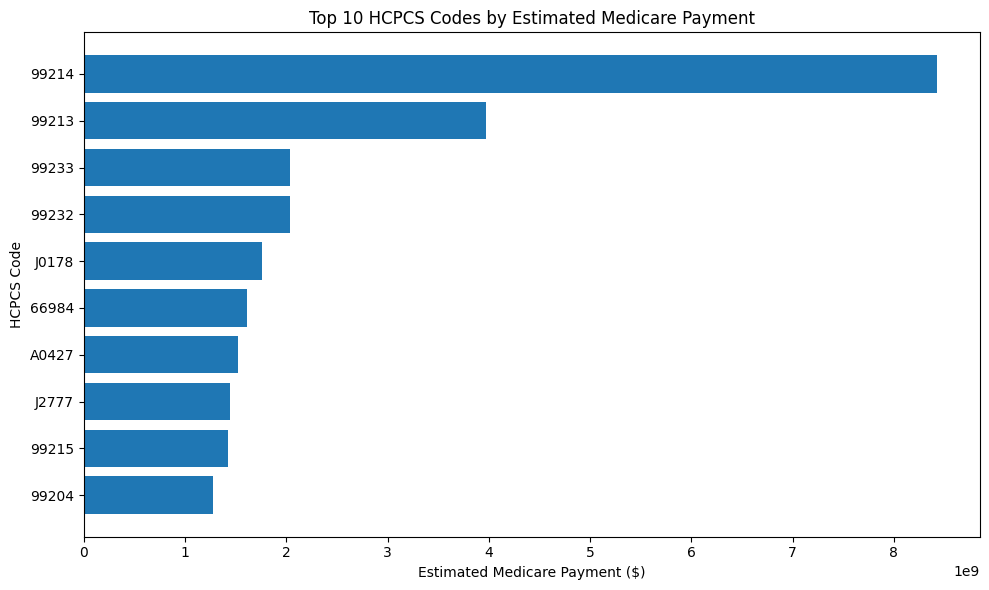

In [11]:
top_hcpcs_pd = (
    hcpcs_payment_summary
    .select(
        "HCPCS_CODE",
        F.round("ESTIMATED_MEDICARE_PAYMENT", 2)
            .alias("ESTIMATED_MEDICARE_PAYMENT")
    )
    .limit(10)
    .toPandas()
    .sort_values("ESTIMATED_MEDICARE_PAYMENT")
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_hcpcs_pd["HCPCS_CODE"],
    top_hcpcs_pd["ESTIMATED_MEDICARE_PAYMENT"]
)
plt.title("Top 10 HCPCS Codes by Estimated Medicare Payment")
plt.xlabel("Estimated Medicare Payment ($)")
plt.ylabel("HCPCS Code")
plt.tight_layout()
plt.show()

In [12]:
#Research Question 3:Which states have the highest Medicare utilization?
state_utilization_summary = (
    master_df
    .filter(F.col("PROVIDER_STATE").isNotNull())
    .groupBy("PROVIDER_STATE")
    .agg(
        F.sum("TOTAL_SERVICES").alias("TOTAL_SERVICES"),
        F.sum("TOTAL_BENEFICIARIES").alias("TOTAL_BENEFICIARIES"),
        F.sum("ESTIMATED_TOTAL_MEDICARE_PAYMENT")
            .alias("ESTIMATED_MEDICARE_PAYMENT"),
        F.countDistinct("NPI").alias("UNIQUE_PROVIDERS")
    )
    .orderBy(F.desc("TOTAL_SERVICES"))
)

state_utilization_display = (
    state_utilization_summary
    .select(
        "PROVIDER_STATE",
        F.round("TOTAL_SERVICES", 0).alias("TOTAL_SERVICES"),
        F.round("TOTAL_BENEFICIARIES", 0)
            .alias("TOTAL_BENEFICIARIES"),
        F.round("ESTIMATED_MEDICARE_PAYMENT", 2)
            .alias("ESTIMATED_MEDICARE_PAYMENT"),
        "UNIQUE_PROVIDERS"
    )
)

state_utilization_display.show(20, truncate=False)

[Stage 33:===================================>                    (30 + 6) / 48]

+--------------+--------------+-------------------+--------------------------+----------------+
|PROVIDER_STATE|TOTAL_SERVICES|TOTAL_BENEFICIARIES|ESTIMATED_MEDICARE_PAYMENT|UNIQUE_PROVIDERS|
+--------------+--------------+-------------------+--------------------------+----------------+
|FL            |3.02165704E8  |7.4337665E7        |9.7050848624E9            |80193           |
|CA            |2.78062432E8  |8.4461634E7        |1.283414124087E10         |96367           |
|TX            |2.14352255E8  |6.2323828E7        |7.4468736098E9            |80776           |
|NY            |1.66619374E8  |5.1748489E7        |6.35237152569E9           |82431           |
|NJ            |1.33337637E8  |4.4195974E7        |4.08115464528E9           |37851           |
|PA            |1.15461096E8  |3.2474871E7        |3.91132516131E9           |59281           |
|IL            |1.10059272E8  |3.255259E7         |3.87113162526E9           |48565           |
|NC            |9.0301211E7   |3.4363559

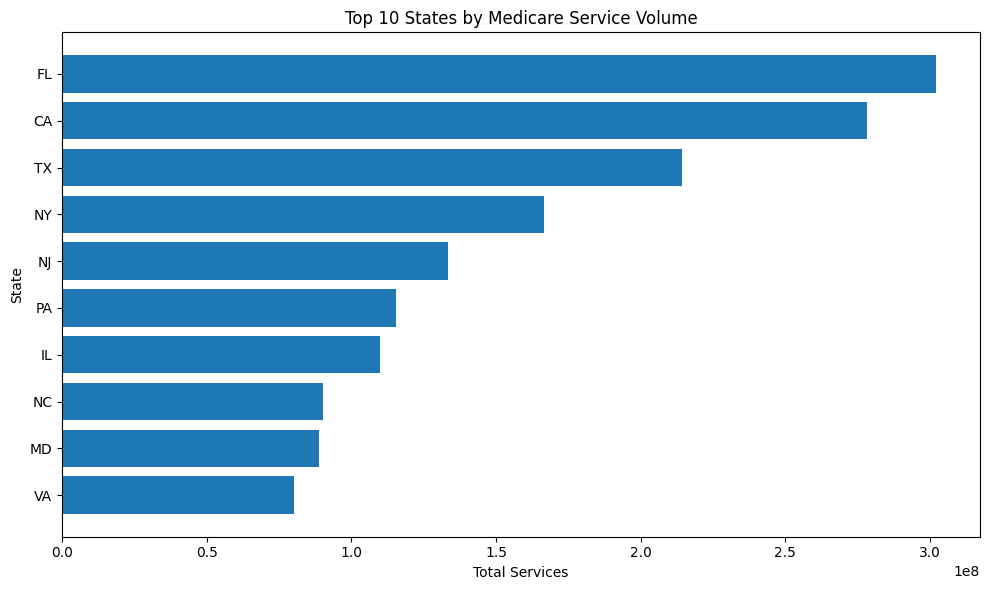

In [13]:
top_states_pd = (
    state_utilization_display
    .limit(10)
    .toPandas()
    .sort_values("TOTAL_SERVICES")
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_states_pd["PROVIDER_STATE"],
    top_states_pd["TOTAL_SERVICES"]
)
plt.title("Top 10 States by Medicare Service Volume")
plt.xlabel("Total Services")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [14]:
#Research Question 4:Which enrollment provider types perform the greatest number of Medicare services?
provider_type_summary = (
    master_df
    .filter(F.col("ENROLLMENT_PROVIDER_TYPE").isNotNull())
    .groupBy("ENROLLMENT_PROVIDER_TYPE")
    .agg(
        F.sum("TOTAL_SERVICES").alias("TOTAL_SERVICES"),
        F.sum("ESTIMATED_TOTAL_MEDICARE_PAYMENT")
            .alias("ESTIMATED_MEDICARE_PAYMENT"),
        F.countDistinct("NPI").alias("UNIQUE_PROVIDERS")
    )
    .orderBy(F.desc("TOTAL_SERVICES"))
)

provider_type_summary.select(
    "ENROLLMENT_PROVIDER_TYPE",
    F.round("TOTAL_SERVICES", 0).alias("TOTAL_SERVICES"),
    F.round("ESTIMATED_MEDICARE_PAYMENT", 2)
        .alias("ESTIMATED_MEDICARE_PAYMENT"),
    "UNIQUE_PROVIDERS"
).show(20, truncate=False)

[Stage 45:=================================================>      (42 + 6) / 48]

+-----------------------------------------------------+--------------+--------------------------+----------------+
|ENROLLMENT_PROVIDER_TYPE                             |TOTAL_SERVICES|ESTIMATED_MEDICARE_PAYMENT|UNIQUE_PROVIDERS|
+-----------------------------------------------------+--------------+--------------------------+----------------+
|PART B SUPPLIER - INDEPENDENT CLINICAL LABORATORY    |2.38515157E8  |5.67377675631E9           |1898            |
|PRACTITIONER - DIAGNOSTIC RADIOLOGY                  |2.04707215E8  |3.60083188325E9           |31813           |
|PRACTITIONER - HEMATOLOGY/ONCOLOGY                   |1.99887617E8  |2.97278441253E9           |8720            |
|PRACTITIONER - PHYSICAL THERAPIST IN PRIVATE PRACTICE|1.68352258E8  |3.39594085734E9           |74795           |
|PRACTITIONER - NURSE PRACTITIONER                    |1.62083368E8  |6.63247073348E9           |185216          |
|PRACTITIONER - RHEUMATOLOGY                          |1.61534094E8  |1.85617744

In [15]:
# Additional Analysis 1
# Which specialties have the highest average payment per service?
# High total spending can result from high volume. This analysis instead compares the average reimbursement level.
# To reduce misleading results, require at least 10,000 services:
specialty_average_payment = (
    master_df
    .filter(F.col("PROVIDER_SPECIALTY").isNotNull())
    .groupBy("PROVIDER_SPECIALTY")
    .agg(
        F.sum("TOTAL_SERVICES").alias("TOTAL_SERVICES"),
        F.sum("ESTIMATED_TOTAL_MEDICARE_PAYMENT")
            .alias("ESTIMATED_MEDICARE_PAYMENT")
    )
    .withColumn(
        "WEIGHTED_AVERAGE_PAYMENT_PER_SERVICE",
        F.col("ESTIMATED_MEDICARE_PAYMENT") /
        F.col("TOTAL_SERVICES")
    )
    .filter(F.col("TOTAL_SERVICES") >= 10000)
    .orderBy(
        F.desc("WEIGHTED_AVERAGE_PAYMENT_PER_SERVICE")
    )
)

specialty_average_payment.select(
    "PROVIDER_SPECIALTY",
    F.round("TOTAL_SERVICES", 0).alias("TOTAL_SERVICES"),
    F.round("WEIGHTED_AVERAGE_PAYMENT_PER_SERVICE", 2)
        .alias("WEIGHTED_AVERAGE_PAYMENT_PER_SERVICE")
).show(20, truncate=False)

[Stage 51:============================================>           (38 + 6) / 48]

+---------------------------------------------+--------------+------------------------------------+
|PROVIDER_SPECIALTY                           |TOTAL_SERVICES|WEIGHTED_AVERAGE_PAYMENT_PER_SERVICE|
+---------------------------------------------+--------------+------------------------------------+
|Thoracic Surgery                             |618116.0      |216.52                              |
|All Other Suppliers                          |298585.0      |212.64                              |
|Cardiac Surgery                              |381558.0      |194.63                              |
|Radiation Therapy Center                     |128458.0      |190.85                              |
|Micrographic Dermatologic Surgery            |1390938.0     |187.7                               |
|Peripheral Vascular Disease                  |79447.0       |178.07                              |
|Opioid Treatment Program                     |1169330.0     |174.7                               |


In [16]:
#Additional Analysis 2
#Which NPIs have the highest estimated Medicare payments?
provider_npi_summary = (
    master_df
    .groupBy(
        "NPI",
        "FIRST_NAME",
        "LAST_NAME",
        "ORGANIZATION_NAME",
        "PROVIDER_STATE"
    )
    .agg(
        F.sum("ESTIMATED_TOTAL_MEDICARE_PAYMENT")
            .alias("ESTIMATED_MEDICARE_PAYMENT"),
        F.sum("TOTAL_SERVICES").alias("TOTAL_SERVICES"),
        F.countDistinct("HCPCS_CODE").alias("DISTINCT_HCPCS_CODES")
    )
    .orderBy(F.desc("ESTIMATED_MEDICARE_PAYMENT"))
)

provider_npi_summary.select(
    "NPI",
    "FIRST_NAME",
    "LAST_NAME",
    "ORGANIZATION_NAME",
    "PROVIDER_STATE",
    F.round("ESTIMATED_MEDICARE_PAYMENT", 2)
        .alias("ESTIMATED_MEDICARE_PAYMENT"),
    F.round("TOTAL_SERVICES", 0).alias("TOTAL_SERVICES"),
    "DISTINCT_HCPCS_CODES"
).show(20, truncate=False)

[Stage 59:============================>                           (12 + 6) / 24]

+----------+----------+---------+--------------------------------------------------+--------------+--------------------------+--------------+--------------------+
|NPI       |FIRST_NAME|LAST_NAME|ORGANIZATION_NAME                                 |PROVIDER_STATE|ESTIMATED_MEDICARE_PAYMENT|TOTAL_SERVICES|DISTINCT_HCPCS_CODES|
+----------+----------+---------+--------------------------------------------------+--------------+--------------------------+--------------+--------------------+
|1629407069|NULL      |NULL     |EXACT SCIENCES LABORATORIES, LLC                  |WI            |3.0635778268E8            |614504.0      |1                   |
|1538144910|NULL      |NULL     |NULL                                              |NC            |2.2436785963E8            |1.6587224E7   |659                 |
|1184045619|NULL      |NULL     |GUARDANT HEALTH INC                               |CA            |2.0962923898E8            |46254.0       |6                   |
|1558672279|NULL      

In [17]:
#Additional Analysis 3
#Place of service comparison
place_of_service_summary = (
    master_df
    .groupBy("PLACE_OF_SERVICE")
    .agg(
        F.sum("TOTAL_SERVICES").alias("TOTAL_SERVICES"),
        F.sum("ESTIMATED_TOTAL_MEDICARE_PAYMENT")
            .alias("ESTIMATED_MEDICARE_PAYMENT"),
        F.avg("AVG_MEDICARE_PAYMENT")
            .alias("AVERAGE_PAYMENT_PER_SERVICE")
    )
    .orderBy(F.desc("TOTAL_SERVICES"))
)

place_of_service_summary.select(
    "PLACE_OF_SERVICE",
    F.round("TOTAL_SERVICES", 0).alias("TOTAL_SERVICES"),
    F.round("ESTIMATED_MEDICARE_PAYMENT", 2)
        .alias("ESTIMATED_MEDICARE_PAYMENT"),
    F.round("AVERAGE_PAYMENT_PER_SERVICE", 2)
        .alias("AVERAGE_PAYMENT_PER_SERVICE")
).show(truncate=False)

[Stage 60:============================>                           (24 + 6) / 48]

+----------------+--------------+--------------------------+---------------------------+
|PLACE_OF_SERVICE|TOTAL_SERVICES|ESTIMATED_MEDICARE_PAYMENT|AVERAGE_PAYMENT_PER_SERVICE|
+----------------+--------------+--------------------------+---------------------------+
|O               |2.289313701E9 |6.819872332594E10         |67.34                      |
|F               |4.67350068E8  |2.909158844044E10         |111.56                     |
+----------------+--------------+--------------------------+---------------------------+



In [18]:
analytics_output = "../data/processed/analytics"

(
    specialty_payment_summary
    .write
    .mode("overwrite")
    .parquet(f"{analytics_output}/specialty_payments")
)

(
    hcpcs_payment_summary
    .write
    .mode("overwrite")
    .parquet(f"{analytics_output}/hcpcs_payments")
)

(
    state_utilization_summary
    .write
    .mode("overwrite")
    .parquet(f"{analytics_output}/state_utilization")
)

(
    provider_type_summary
    .write
    .mode("overwrite")
    .parquet(f"{analytics_output}/provider_types")
)

print("Analytical summary datasets saved.")

[Stage 102:=========================================>             (36 + 6) / 48]

Analytical summary datasets saved.


In [19]:
presentation_output = "../data/processed/presentation_tables"

(
    specialty_payment_display
    .limit(20)
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(f"{presentation_output}/top_specialties")
)

(
    state_utilization_display
    .limit(20)
    .coalesce(1)
    .write
    .mode("overwrite")
    .option("header", True)
    .csv(f"{presentation_output}/top_states")
)

print("Presentation tables exported.")

[Stage 121:=================================================>     (43 + 5) / 48]

Presentation tables exported.


In [20]:
## Analytical Summary

#This notebook used Apache Spark to analyze approximately 9.78 million integrated Medicare provider-service records.

#The analyses examined:

#- Provider specialties generating the highest estimated Medicare payments
#- HCPCS procedures accounting for the greatest estimated spending
#- States with the highest service utilization
#- Enrollment provider types performing the greatest number of services
#- Specialties with high weighted average reimbursement
#- High-payment provider NPIs requiring further analytical review
#- Differences in service volume and reimbursement by place of service

#The results will be used to create the final presentation, support the AWS demonstration, and explain the project's business findings.